# PageRank Python Implementation

In [1]:
import sys

!{sys.executable} -m pip install nbimporter

In [2]:
import numpy as np
import nbimporter

"""
    PageRank
    
    damping : float, optional
      Damping parameter for PageRank.
      
    iteration : integer, optional
      Maximum number of iterations in method solver.
  
    tol : float, optional
      Error tolerance used to check convergence in method solver.
"""

In [3]:
def PageRank_iteration(graph, damping):
    node_list= graph.nodes
    
    for node in node_list:
        node.update_pagerank(damping, len(graph.nodes))
    
    graph.normalize_pagerank()

    
def PageRank(graph, damping=0.15, iteration=100, tol=1.0e-6):
    last_PR= []
    
    for i in range(iteration):
        PageRank_iteration(graph, damping)
        this_PR= graph.get_pagerank_list()
        
        # Convergence check, l1 norm
        if (i> 0):
            N= len(this_PR)
            error= sum(abs(np.subtract(this_PR, last_PR)))
            
            if error< (N* tol):
                return i+ 1
            
        last_PR= this_PR

In [4]:
def run_PageRank(graph, iteration= 100, damping_factor= 0.85, tolerance= 1.0e-6, verbose= False):

    count= PageRank(graph, damping_factor, iteration, tolerance)
    
    ids= graph.get_pr_index_list()
    prs= graph.get_pagerank_list()
    
    pr_list= dict(zip(ids, prs.T))
    
    if (verbose== True):
        print(np.round(pr_vals,5))
        print('Convergence in', count, 'iterations')
    
    return pr_list.copy()

In [5]:
import GraphPR as gpr

graph= gpr.init_graph('datasets/graph.txt')

run_PageRank(graph)

{1.0: 0.2802872,
 2.0: 0.15876444,
 3.0: 0.13888213,
 4.0: 0.10821984,
 5.0: 0.18419828,
 6.0: 0.060570706,
 7.0: 0.069077395}

In [6]:
graph.print_graph()

1.0 is linded to 2.0 edge weight 1.0
    is linded to 3.0 edge weight 1.0
    is linded to 5.0 edge weight 1.0
    is linded to 6.0 edge weight 1.0
2.0 is linded to 1.0 edge weight 1.0
    is linded to 3.0 edge weight 1.0
    is linded to 4.0 edge weight 1.0
3.0 is linded to 1.0 edge weight 1.0
    is linded to 4.0 edge weight 1.0
    is linded to 5.0 edge weight 1.0
4.0 is linded to 1.0 edge weight 1.0
    is linded to 5.0 edge weight 1.0
5.0 is linded to 1.0 edge weight 1.0
    is linded to 4.0 edge weight 1.0
    is linded to 6.0 edge weight 1.0
    is linded to 7.0 edge weight 1.0
6.0 is linded to 5.0 edge weight 1.0
7.0 is linded to 1.0 edge weight 1.0


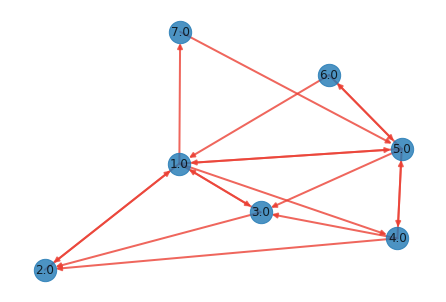

In [9]:
graph.display()